In [4]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [5]:
# Load Dataset CIFAR-10
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

# Gabungkan seluruh data agar kita bisa membaginya dari awal secara presisi
X_all = np.concatenate((x_train_full, x_test_full), axis=0)
y_all = np.concatenate((y_train_full, y_test_full), axis=0).flatten()

# Filter Hanya 2 Kelas (Misal: 0 = Airplane, 1 = Automobile)
class_0 = 0
class_1 = 1
mask = (y_all == class_0) | (y_all == class_1)

X_filtered = X_all[mask]
y_filtered = y_all[mask]
y_filtered = np.where(y_filtered == class_0, 0, 1)

# Split Dataset 
# 70% untuk Training, sisakan 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.30, random_state=42, stratify=y_filtered
)

# Bagi sisa 30% menjadi dua bagian sama rata (15% Val, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Total data 2 kelas (Airplane vs Automobile): {len(X_filtered)}")
print(f"Jumlah Training (70%): {len(X_train)}")
print(f"Jumlah Validation (15%): {len(X_val)}")
print(f"Jumlah Testing (15%): {len(X_test)}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 492s 3us/step
Total data 2 kelas (Airplane vs Automobile): 12000
Jumlah Training (70%): 8400
Jumlah Validation (15%): 1800
Jumlah Testing (15%): 1800


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Membangun Arsitektur CNN from Scratch (Versi Syntax Terbaru)
model_cnn = Sequential([
    # Tambahkan layer Input 
    Input(shape=(32, 32, 3)),
    
    # Block 1 
    Conv2D(32, (3, 3), activation='relu'), # input_shape dihapus dari sini
    MaxPooling2D((2, 2)),
    
    # Block 2 
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Block 3 
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Flatten
    Flatten(),
    
    # Fully Connected Layer (Dense)
    Dense(128, activation='relu'),
    
    # Regularisasi Dropout
    Dropout(0.5), 
    
    # Output Layer (Biner)
    Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

Memulai proses training...
Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.7835 - loss: 0.4523 - val_accuracy: 0.8706 - val_loss: 0.3021
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.8895 - loss: 0.2709 - val_accuracy: 0.9044 - val_loss: 0.2293
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9150 - loss: 0.2091 - val_accuracy: 0.8972 - val_loss: 0.2577
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9319 - loss: 0.1692 - val_accuracy: 0.9200 - val_loss: 0.2055
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9475 - loss: 0.1372 - val_accuracy: 0.9294 - val_loss: 0.1897
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9543 - loss: 0.1216 - val_accuracy: 0.9200 - val_loss: 0.2152
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9669 - loss: 0.0900 - val_accuracy: 0.9372 - val_loss: 0.1766
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accurac

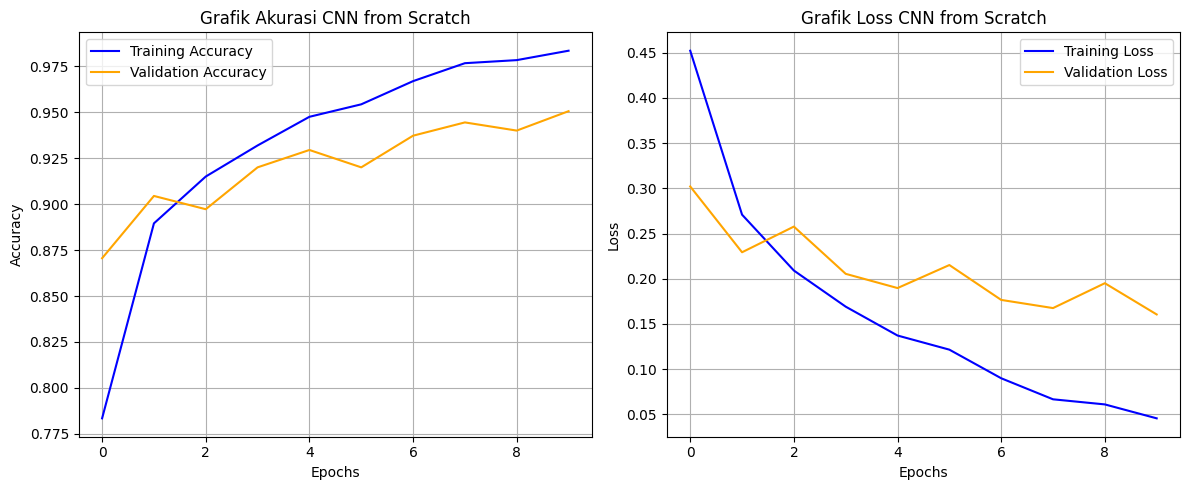

In [8]:
# 1. Melatih Model (Training)
# Proses ini mungkin memakan waktu beberapa menit karena menggunakan CPU
print("Memulai proses training...")
history = model_cnn.fit(
    X_train, y_train,
    epochs=10, 
    batch_size=32,
    validation_data=(X_val, y_val)
)

# 2. Evaluasi Model pada Data Testing
print("\nMengevaluasi model pada data testing (15% data tak terlihat)...")
test_loss, test_accuracy = model_cnn.evaluate(X_test, y_test)
print(f"Akurasi Testing: {test_accuracy * 100:.2f}%")

# 3. Visualisasi Grafik Loss dan Akurasi
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Grafik Akurasi CNN from Scratch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Grafik Loss CNN from Scratch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [1]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

base_dir = 'cats_and_dogs_filtered/train'
cats_dir = os.path.join(base_dir, 'cats')
dogs_dir = os.path.join(base_dir, 'dogs')

# MobileNetV2 optimal menerima ukuran gambar 160x160
IMG_SIZE = (160, 160)
images = []
labels = []

print("Membaca gambar dari folder lokal ke dalam memori...")

# Load 150 Kucing (Label 0)
for img_name in os.listdir(cats_dir)[:150]:
    img_path = os.path.join(cats_dir, img_name)
    img = load_img(img_path, target_size=IMG_SIZE)
    images.append(img_to_array(img))
    labels.append(0)

# Load 150 Anjing (Label 1)
for img_name in os.listdir(dogs_dir)[:150]:
    img_path = os.path.join(dogs_dir, img_name)
    img = load_img(img_path, target_size=IMG_SIZE)
    images.append(img_to_array(img))
    labels.append(1)

X_tl = np.array(images)
y_tl = np.array(labels)

# Normalisasi piksel (Skala 0 - 1)
X_tl = X_tl / 255.0

# Split Dataset (70% Train, 15% Val, 15% Test)
X_train_tl, X_temp_tl, y_train_tl, y_temp_tl = train_test_split(
    X_tl, y_tl, test_size=0.30, random_state=42, stratify=y_tl
)
X_val_tl, X_test_tl, y_val_tl, y_test_tl = train_test_split(
    X_temp_tl, y_temp_tl, test_size=0.50, random_state=42, stratify=y_temp_tl
)

print(f"\nProses selesai!")
print(f"Total Data: {len(X_tl)} gambar")
print(f"Jumlah Training (70%): {len(X_train_tl)}")
print(f"Jumlah Validation (15%): {len(X_val_tl)}")
print(f"Jumlah Testing (15%): {len(X_test_tl)}")

Membaca gambar dari folder lokal ke dalam memori...

Proses selesai!
Total Data: 300 gambar
Jumlah Training (70%): 210
Jumlah Validation (15%): 45
Jumlah Testing (15%): 45


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Memulai proses training Transfer Learning (MobileNetV2)...
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8143 - loss: 0.3880 - val_accuracy: 0.9778 - val_loss: 0.0578
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 757ms/step - accuracy: 0.9619 - loss: 0.0831 - val_accuracy: 1.0000 - val_loss: 0.0353
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 681ms/step - accuracy: 0.9905 - loss: 0.0371 - val_accuracy: 1.0000 - val_loss: 0.0191
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 550ms/step - accuracy: 1.0000 - loss: 0.0107 - val_accuracy: 0.9778 - val_loss: 0.0326
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 514ms/step - accuracy: 1.0000 - loss: 0.0118 - val_accuracy: 1.0000 - val_loss: 0.0182
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 560ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 1.0000 - val_loss: 0.0157
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 511ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9778 - val_loss: 0.0210
Epoch 8/10
7

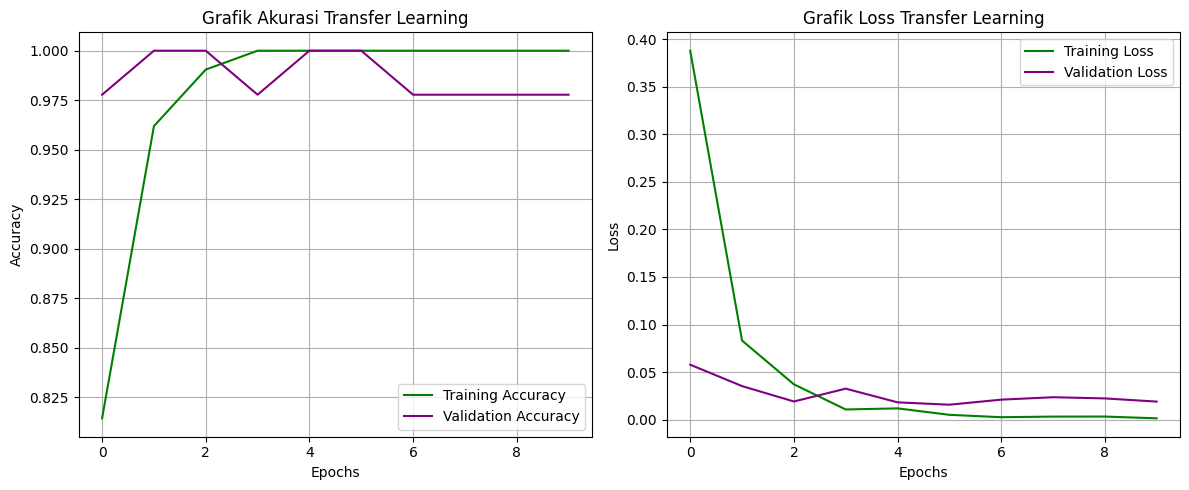

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
import tensorflow as tf
import matplotlib.pyplot as plt

# Load Pretrained Model (MobileNetV2)
base_model = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')

# Strategi FEATURE EXTRACTION: Bekukan semua layer bawaan
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x) 
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
predictions = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model_tl = Model(inputs=base_model.input, outputs=predictions)

# Kompilasi dan Training
model_tl.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                 loss='binary_crossentropy', 
                 metrics=['accuracy'])

print("Memulai proses training Transfer Learning (MobileNetV2)...")
history_tl = model_tl.fit(
    X_train_tl, y_train_tl, 
    epochs=10, 
    batch_size=32, 
    validation_data=(X_val_tl, y_val_tl)
)

# Visualisasi Grafik Loss dan Akurasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('Grafik Akurasi Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_tl.history['loss'], label='Training Loss', color='green')
plt.plot(history_tl.history['val_loss'], label='Validation Loss', color='purple')
plt.title('Grafik Loss Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Membuat prediksi pada data testing Transfer Learning...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step


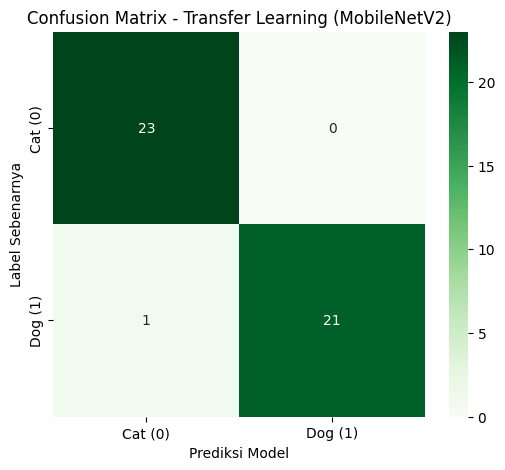


Menampilkan contoh prediksi BENAR (Transfer Learning):


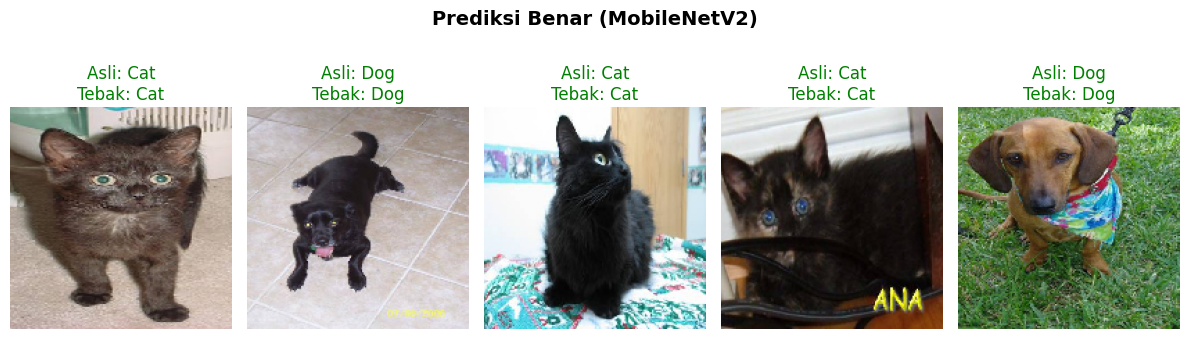


Menampilkan contoh prediksi SALAH (Transfer Learning):


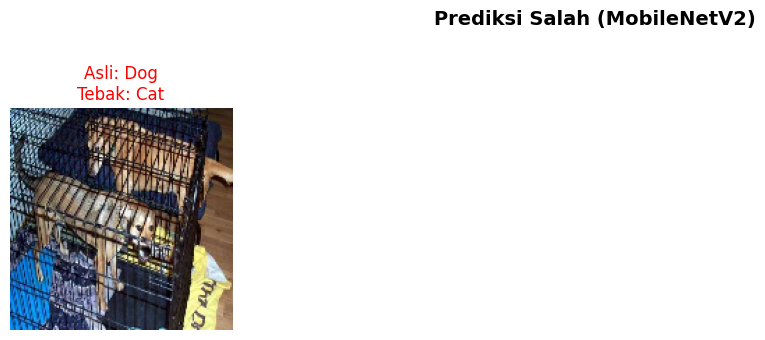

In [6]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Definisi ulang fungsi plot_samples agar tidak error
def plot_samples(indices, title, X, y_true, y_p):
    plt.figure(figsize=(12, 4))
    plt.suptitle(title, fontsize=14, fontweight='bold')
    # Tampilkan maksimal 5 gambar
    for i in range(min(5, len(indices))):
        idx = indices[i]
        plt.subplot(1, 5, i+1)
        plt.imshow(X[idx])
        
        # Mapping label biner ke teks (0: Cat, 1: Dog)
        label_true = "Dog" if y_true[idx] == 1 else "Cat"
        label_pred = "Dog" if y_p[idx] == 1 else "Cat"
        
        # Warna hijau jika benar, merah jika salah
        color = "green" if y_true[idx] == y_p[idx] else "red"
        plt.title(f"Asli: {label_true}\nTebak: {label_pred}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Melakukan Prediksi pada Data Testing (Cats vs Dogs)
print("Membuat prediksi pada data testing Transfer Learning...")
y_pred_prob_tl = model_tl.predict(X_test_tl)
y_pred_tl = (y_pred_prob_tl > 0.5).astype(int).flatten() 

# Visualisasi Confusion Matrix
cm_tl = confusion_matrix(y_test_tl, y_pred_tl)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Cat (0)', 'Dog (1)'], 
            yticklabels=['Cat (0)', 'Dog (1)'])
plt.title('Confusion Matrix - Transfer Learning (MobileNetV2)')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.show()

# Mencari Indeks Prediksi Benar dan Salah
correct_indices_tl = np.where(y_pred_tl == y_test_tl)[0]
incorrect_indices_tl = np.where(y_pred_tl != y_test_tl)[0]

# Tampilkan Gambar Prediksi Benar
print("\nMenampilkan contoh prediksi BENAR (Transfer Learning):")
plot_samples(correct_indices_tl, "Prediksi Benar (MobileNetV2)", X_test_tl, y_test_tl, y_pred_tl)

# Tampilkan Gambar Prediksi Salah
# (Catatan: Jika akurasi modelmu 100%, mungkin tidak ada gambar yang salah)
if len(incorrect_indices_tl) > 0:
    print("\nMenampilkan contoh prediksi SALAH (Transfer Learning):")
    plot_samples(incorrect_indices_tl, "Prediksi Salah (MobileNetV2)", X_test_tl, y_test_tl, y_pred_tl)
else:
    print("\nLuar biasa! Tidak ada prediksi yang salah pada data testing.")